# 9 — Metadata + Features

Agrega las features calculadas (de `Features_Damian/`) como columnas al dataframe de metadata.

**Fuentes de metadata**:
- `hybrid_metadata/UON_ana_out/metadata/` — 29 sujetos numéricos (dataset UON)
- `hybrid_metadata/Hybrid_ana_out/metadata/` — 16 sujetos S-prefijados (dataset Hybrid/UBA)

**Join key**: `(subject, trial, rank)` → `(sujeto, imagen_folder, fixation_index)`
- `trial` (1-indexed) en metadata = `trials.thisN + 1` en CSV conductual
- `rank` (1-indexed) en metadata = `fixation` (0-indexed) en `features.json`
- Solo fijaciones `phase=='vs'`, `bad==0`, `inrange==True`, `present==True` reciben features; el resto queda NaN.

**Output**: `../hybrid_metadata/all_metadata_with_features.parquet`

In [1]:
import sys, json
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.insert(0, '..')

UON_META_DIR    = Path('../hybrid_metadata/UON_ana_out/metadata')
HYBRID_META_DIR = Path('../hybrid_metadata/Hybrid_ana_out/metadata')
FEATURES_DIR    = Path('../Features_Damian')
BH_UON_DIR      = Path('../hybrid_metadata/UON')
BH_UBA_DIR      = Path('../hybrid_metadata/UBA')

FEAT_COLS = [
    'saliencia_media', 'saliencia_mediana', 'saliencia_pixel',
    'similitud_media', 'similitud_mediana', 'similitud_pixel',
    'evidencia_visual',
    'competencia_fp_var', 'competencia_fp_media', 'competencia_fp_max',
    'posterior',
    'entropia_prior_saliencia', 'entropia_prior_modelo', 'entropia_posterior',
    'ganancia_informacion',
    'eig_optimo', 'eig_en_fijacion', 'gap_entropia',
    'modelo_fix_y', 'modelo_fix_x',
    'distancia_grilla', 'distancia_pixels',
    'competencia_ratio_mayor', 'competencia_ratio_segundo_mayor',
    'competencia_ratio', 'competencia_densidad', 'competencia_densidad_norm',
]

print('Setup OK')

Setup OK


In [2]:
# ── 1. Build trial→image lookup from behavioral CSVs ────────────────────────
# UON  : sujetos numéricos  → UON/{subject}_*.csv
# Hybrid: sujetos S-prefijados → UBA/{subject}/*.csv

def get_trial_image_map(subject: str) -> dict:
    """trial_id (1-indexed int) → imagen_folder (str, sin .jpg)"""
    if subject.startswith('S'):
        bh_files = sorted(BH_UBA_DIR.glob(f'{subject}/*.csv'))
    else:
        bh_files = sorted(BH_UON_DIR.glob(f'{subject}_*.csv'))

    if not bh_files:
        return {}

    bh = pd.read_csv(bh_files[0], usecols=['trials.thisN', 'searchimage'],
                     encoding='utf-8-sig')
    mapping = (
        bh.dropna(subset=['searchimage'])
          .drop_duplicates('trials.thisN')
          .set_index('trials.thisN')['searchimage']
    )
    # trials.thisN es 0-indexed; trial en metadata es 1-indexed
    return {int(k) + 1: v.replace('.jpg', '') for k, v in mapping.items()}

# Verificación
for subj in ['286470', 'S101']:
    m = get_trial_image_map(subj)
    print(f'{subj}: {len(m)} trials  |  trial 3 → {m.get(3)}')

286470: 210 trials  |  trial 3 → cmp_shelves_029_book_002
S101: 210 trials  |  trial 3 → cmp_building_023_cat_010


In [3]:
# ── 2. Flatten all features.json into a DataFrame ───────────────────────────

records = []
for feat_path in sorted(FEATURES_DIR.glob('*/*/features.json')):
    img_folder = feat_path.parts[-3]
    subject    = feat_path.parts[-2]
    with open(feat_path) as f:
        data = json.load(f)
    for fij in data.get('fijaciones', []):
        row = {'subject': subject, 'img_folder': img_folder,
               'fixation_idx': fij['fixation']}
        for col in FEAT_COLS:
            row[col] = fij.get(col)
        records.append(row)

df_feats = pd.DataFrame(records)
# Convertir a numérico donde corresponda
for col in FEAT_COLS:
    df_feats[col] = pd.to_numeric(df_feats[col], errors='coerce')

print(f'Total fijaciones con features: {len(df_feats):,}')
print(f'Sujetos: {df_feats["subject"].nunique()}')
print(f'Imágenes: {df_feats["img_folder"].nunique()}')
df_feats.head(2)

Total fijaciones con features: 61,252
Sujetos: 45
Imágenes: 102


,subject,img_folder,fixation_idx,saliencia_media,saliencia_mediana,saliencia_pixel,similitud_media,similitud_mediana,similitud_pixel,evidencia_visual,...,gap_entropia,modelo_fix_y,modelo_fix_x,distancia_grilla,distancia_pixels,competencia_ratio_mayor,competencia_ratio_segundo_mayor,competencia_ratio,competencia_densidad,competencia_densidad_norm
0,117969,cmp_africansavanna_003_wildanimals_003,0,0.374502,0.380392,0.000000,0.001214,0.000000,0.000000,-3.475047,...,NaN,NaN,NaN,NaN,NaN,0.246307,0.240675,0.977135,2,0.002604
1,117969,cmp_africansavanna_003_wildanimals_003,1,0.026225,0.027451,0.007843,0.007426,0.007843,0.015686,-5.739872,...,0.202254,17.0,13.0,12.041595,385.331027,0.218843,0.214153,0.978570,2,0.002604


In [4]:
# ── 3. Load metadata CSVs from both sources ──────────────────────────────────

META_SOURCES = [
    (UON_META_DIR,    'UON'),
    (HYBRID_META_DIR, 'Hybrid'),
]

dfs_meta = []
for meta_dir, dataset in META_SOURCES:
    for csv_path in sorted(meta_dir.glob('*_full_metadata.csv')):
        subject = csv_path.stem.replace('_full_metadata', '')
        df = pd.read_csv(csv_path)
        df['subject'] = subject
        df['dataset'] = dataset

        trial_map = get_trial_image_map(subject)
        if trial_map:
            df['img_folder'] = df['trial'].map(
                lambda t, m=trial_map: m.get(int(t)) if pd.notna(t) else None
            )
        else:
            df['img_folder'] = None
        dfs_meta.append(df)

meta = pd.concat(dfs_meta, ignore_index=True)
meta['rank'] = pd.to_numeric(meta['rank'], errors='coerce')
meta['fixation_idx'] = (meta['rank'] - 1).where(meta['rank'].notna()).astype('Int64')

print(f'Metadata total rows : {len(meta):,}')
print(f'Sujetos             : {meta["subject"].nunique()}  '
      f'(UON={meta[meta["dataset"]=="UON"]["subject"].nunique()}, '
      f'Hybrid={meta[meta["dataset"]=="Hybrid"]["subject"].nunique()})')
print(f'Con img_folder      : {meta["img_folder"].notna().sum():,}')

Metadata total rows : 1,151,998
Sujetos             : 45  (UON=29, Hybrid=16)
Con img_folder      : 643,289


In [5]:
# ── 4. Merge features → metadata ────────────────────────────────────────────
# Solo fijaciones válidas en fase VS reciben features

fix_mask = (
    (meta['type']    == 'fixation') &
    (meta['phase']   == 'vs')       &
    (meta['bad']     == 0)          &
    (meta['inrange'] == True)       &
    (meta['present'] == True)       &
    meta['img_folder'].notna()      &
    meta['fixation_idx'].notna()
)
print(f'Fijaciones candidatas para join: {fix_mask.sum():,}')

# Merge por (subject, img_folder, fixation_idx)
meta_fix = meta.loc[fix_mask, ['subject', 'img_folder', 'fixation_idx']].copy()
meta_fix['fixation_idx'] = meta_fix['fixation_idx'].astype(int)

merged_fix = meta_fix.merge(
    df_feats,
    on=['subject', 'img_folder', 'fixation_idx'],
    how='left'
)

# Asignar features de vuelta al dataframe completo
for col in FEAT_COLS:
    meta[col] = np.nan

meta.loc[fix_mask, FEAT_COLS] = merged_fix[FEAT_COLS].values

matched = meta.loc[fix_mask, 'eig_optimo'].notna().sum()
print(f'Fijaciones con features asignadas: {matched:,} / {fix_mask.sum():,} ({100*matched/fix_mask.sum():.1f}%)')

Fijaciones candidatas para join: 67,287
Fijaciones con features asignadas: 56,751 / 67,287 (84.3%)


# ── 5. Cobertura por sujeto ──────────────────────────────────────────────────

cov = (
    meta[fix_mask]
    .groupby('subject')[['eig_optimo']]
    .apply(lambda g: pd.Series({
        'n_fix_candidatas': len(g),
        'n_con_features': g['eig_optimo'].notna().sum(),
        'cobertura_pct': 100 * g['eig_optimo'].notna().sum() / len(g)
    }), include_groups=False)
    .reset_index()
)
print(cov.to_string(index=False, float_format='%.1f'))

In [6]:
# ── Val A: Integridad del merge ───────────────────────────────────────────────
# 1. merged_fix no debe tener más filas que fix_mask (producto cartesiano indicaría
#    claves duplicadas en df_feats).
# 2. Las columnas de join no deben tener NaN en df_feats.

errors = []

n_cand  = fix_mask.sum()
n_merge = len(merged_fix)
if n_merge != n_cand:
    errors.append(f'MERGE SIZE: {n_merge} filas vs {n_cand} candidatas (diff={n_merge - n_cand})')

# Claves duplicadas en df_feats → cualquier (subject, img_folder, fixation_idx) repetido
dup_keys = df_feats.duplicated(subset=['subject', 'img_folder', 'fixation_idx']).sum()
if dup_keys:
    errors.append(f'DUPLICADOS en df_feats: {dup_keys} claves repetidas')

# NaN en las claves de join
for col in ['subject', 'img_folder', 'fixation_idx']:
    n_nan = df_feats[col].isna().sum()
    if n_nan:
        errors.append(f'NaN en df_feats["{col}"]: {n_nan}')

if errors:
    for e in errors:
        print(f'[ERROR] {e}')
else:
    print(f'[OK] merge size       : {n_merge} == {n_cand}')
    print(f'[OK] sin duplicados   : df_feats tiene claves únicas')
    print(f'[OK] sin NaN en claves: subject / img_folder / fixation_idx')

[OK] merge size       : 67287 == 67287
[OK] sin duplicados   : df_feats tiene claves únicas
[OK] sin NaN en claves: subject / img_folder / fixation_idx


In [7]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151998 entries, 0 to 1151997
Data columns (total 60 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   type                             1151998 non-null  object 
 1   edftype                          830151 non-null   float64
 2   latency                          1151998 non-null  float64
 3   urevent                          1117768 non-null  float64
 4   duration                         1151998 non-null  int64  
 5   endtime                          1117768 non-null  float64
 6   sac_amplitude                    1117768 non-null  float64
 7   sac_endpos_x                     1117768 non-null  float64
 8   sac_endpos_y                     1117768 non-null  float64
 9   sac_startpos_x                   1117768 non-null  float64
 10  sac_startpos_y                   1117768 non-null  float64
 11  sac_vmax                         1117768 non-null 

In [8]:
feat = ['saliencia_media',
 'saliencia_mediana',
 'saliencia_pixel',
 'similitud_media',
 'similitud_mediana',
 'similitud_pixel',
 'evidencia_visual',
 'competencia_fp_var',
 'competencia_fp_media',
 'competencia_fp_max',
 'posterior',
 'entropia_prior_saliencia',
 'entropia_prior_modelo',
 'entropia_posterior',
 'ganancia_informacion',
 'eig_optimo',
 'eig_en_fijacion',
 'gap_entropia',
 'modelo_fix_y',
 'modelo_fix_x',
 'distancia_grilla',
 'distancia_pixels',
 'competencia_ratio_mayor',
 'competencia_ratio_segundo_mayor',
 'competencia_ratio',
 'competencia_densidad',
 'competencia_densidad_norm']

In [9]:
# Filas que no tienen nan en alguna feature
meta[meta[feat].notna().all(axis=1)]

,type,edftype,latency,urevent,duration,endtime,sac_amplitude,sac_endpos_x,sac_endpos_y,sac_startpos_x,...,gap_entropia,modelo_fix_y,modelo_fix_x,distancia_grilla,distancia_pixels,competencia_ratio_mayor,competencia_ratio_segundo_mayor,competencia_ratio,competencia_densidad,competencia_densidad_norm
151,fixation,0.0,97577.0,21606.0,135,0.0,3.214180,514.965698,419.671478,694.192200,...,0.073553,9.0,17.0,12.000000,384.000000,0.164620,0.157726,0.958121,4.0,0.005208
155,fixation,0.0,97727.0,21607.0,84,0.0,4.470777,702.206055,238.864655,533.982361,...,0.053868,9.0,17.0,8.944272,286.216701,0.160873,0.153753,0.955745,3.0,0.003906
159,fixation,0.0,97824.0,21608.0,97,0.0,5.485288,973.360413,373.357605,695.079712,...,0.037712,9.0,17.0,2.236068,71.554175,0.197475,0.181303,0.918107,1.0,0.001302
163,fixation,0.0,97947.0,21609.0,121,0.0,5.563871,1258.163086,252.789246,970.373474,...,0.129719,10.0,17.0,7.810250,249.927990,0.139143,0.136927,0.984079,2.0,0.002604
167,fixation,0.0,98085.0,21610.0,90,0.0,4.163395,1106.927368,94.944351,1262.894409,...,0.108438,10.0,18.0,9.055385,289.772324,0.130044,0.128261,0.986286,3.0,0.003906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151904,fixation,NaN,1816064.0,35257.0,158,0.0,4.900000,1120.848755,210.396729,1110.926392,...,3.648718,9.0,19.0,5.000000,160.000000,3.957235,3.515199,0.888297,1.0,0.001302
1151908,fixation,NaN,1818653.0,35258.0,106,0.0,3.935663,1094.657227,868.965698,1308.876831,...,3.956015,9.0,18.0,10.049876,321.596020,4.202888,3.279181,0.780221,1.0,0.001302
1151912,fixation,NaN,1819033.0,35259.0,106,0.0,5.946576,1340.560181,587.559998,1427.297241,...,4.199607,9.0,18.0,7.615773,243.704739,4.033091,3.107500,0.770501,1.0,0.001302
1151955,fixation,NaN,1823604.0,35277.0,68,0.0,1.456737,1153.046631,606.691101,1135.076416,...,0.310843,12.0,18.0,3.162278,101.192885,0.548640,0.490990,0.894922,1.0,0.001302


In [10]:
# ── 7. Guardar ───────────────────────────────────────────────────────────────

out_path = Path('../hybrid_metadata/all_metadata_with_features.parquet')

try:
    meta.to_parquet(out_path, index=False)
    print(f'Guardado (parquet): {out_path}')
except ImportError:
    # pyarrow/fastparquet no instalado → fallback a CSV gzip
    out_path = out_path.with_suffix('.csv.gz')
    meta.to_csv(out_path, index=False, compression='gzip')
    print(f'Guardado (csv.gz) : {out_path}')
    print('  Para usar parquet: pip install pyarrow')

print(f'Shape   : {meta.shape}')
print(f'Datasets: {meta["dataset"].value_counts().to_dict()}')
print(f'Columnas nuevas ({len(FEAT_COLS)}): {FEAT_COLS}')

Guardado (csv.gz) : ../hybrid_metadata/all_metadata_with_features.csv.gz
  Para usar parquet: pip install pyarrow
Shape   : (1151998, 60)
Datasets: {'UON': 861435, 'Hybrid': 290563}
Columnas nuevas (27): ['saliencia_media', 'saliencia_mediana', 'saliencia_pixel', 'similitud_media', 'similitud_mediana', 'similitud_pixel', 'evidencia_visual', 'competencia_fp_var', 'competencia_fp_media', 'competencia_fp_max', 'posterior', 'entropia_prior_saliencia', 'entropia_prior_modelo', 'entropia_posterior', 'ganancia_informacion', 'eig_optimo', 'eig_en_fijacion', 'gap_entropia', 'modelo_fix_y', 'modelo_fix_x', 'distancia_grilla', 'distancia_pixels', 'competencia_ratio_mayor', 'competencia_ratio_segundo_mayor', 'competencia_ratio', 'competencia_densidad', 'competencia_densidad_norm']


In [11]:
meta[['type','subject','latency']].value_counts()

type        subject  latency     
L_fixation  244389   1.285681e+06    2
100         117969   6.414993e+04    1
fixation    S115     9.089240e+05    1
                     9.099350e+05    1
                     9.097780e+05    1
                                    ..
L_saccade   664304   5.634312e+05    1
                     5.635002e+05    1
                     5.636052e+05    1
                     5.637312e+05    1
vs          S119     1.828123e+06    1
Name: count, Length: 1151997, dtype: int64

In [12]:
meta[meta[feat].notna().any(axis=1)]['type'].value_counts()

type
fixation    61252
Name: count, dtype: int64

In [13]:
# ── Val C: Spot-check de valores numéricos ───────────────────────────────────
# Para un (sujeto, trial) concreto, compara los valores de cada fijación
# en el dataframe enriquecido contra los valores crudos del features.json.
# Verifica también que rank 1 → fixation_idx 0 (no off-by-one).

SPOT_SUBJECT = '286470'
SPOT_TRIAL   = 3          # trial con fijaciones para ese sujeto

trial_map_spot = get_trial_image_map(SPOT_SUBJECT)
img_folder_spot = trial_map_spot[SPOT_TRIAL]
feat_path_spot  = FEATURES_DIR / img_folder_spot / SPOT_SUBJECT / 'features.json'

with open(feat_path_spot) as f:
    raw_fijaciones = {fij['fixation']: fij for fij in json.load(f)['fijaciones']}

# Fijaciones del trial en el dataframe enriquecido
spot_df = meta[
    (meta['subject'] == SPOT_SUBJECT) &
    (meta['trial']   == SPOT_TRIAL)   &
    (meta['type']    == 'fixation')   &
    (meta['phase']   == 'vs')         &
    (meta['bad']     == 0)            &
    (meta['inrange'] == True)         &
    (meta['present'] == True)
].sort_values('rank').reset_index(drop=True)

SPOT_FEATS = ['eig_optimo', 'saliencia_media', 'similitud_media', 'entropia_posterior', 'posterior']
TOLS = {'eig_optimo': 1e-6, 'saliencia_media': 1e-6, 'similitud_media': 1e-6,
        'entropia_posterior': 1e-6, 'posterior': 1e-10}

print(f'Sujeto={SPOT_SUBJECT}  Trial={SPOT_TRIAL}  Imagen={img_folder_spot}')
print(f'N fijaciones en metadata: {len(spot_df)}  |  N en features.json: {len(raw_fijaciones)}')
print()

all_ok = True
print(f'{"rank":>5}  {"fix_idx":>7}  {"feature":<25}  {"df_value":>14}  {"json_value":>14}  {"match":>6}')
print('-' * 80)
for _, row in spot_df.iterrows():
    rank     = int(row['rank'])
    fix_idx  = rank - 1
    raw      = raw_fijaciones.get(fix_idx)
    for feat in SPOT_FEATS:
        df_val   = row[feat]
        json_val = float(raw[feat]) if (raw and raw.get(feat) is not None) else np.nan
        tol      = TOLS[feat]
        if pd.isna(df_val) and pd.isna(json_val):
            match = 'NaN/NaN'
        elif pd.isna(df_val) or pd.isna(json_val):
            match = '❌ MISMATCH'
            all_ok = False
        elif abs(df_val - json_val) < tol:
            match = 'OK'
        else:
            match = f'❌ diff={df_val - json_val:.2e}'
            all_ok = False
        print(f'{rank:>5}  {fix_idx:>7}  {feat:<25}  {df_val:>14.8f}  {json_val:>14.8f}  {match:>6}')

print()
print('Resultado:', '[OK] Todos los valores coinciden' if all_ok else '[ERROR] Hay discrepancias')

Sujeto=286470  Trial=3  Imagen=cmp_shelves_029_book_002
N fijaciones en metadata: 28  |  N en features.json: 27

 rank  fix_idx  feature                          df_value      json_value   match
--------------------------------------------------------------------------------
    1        0  eig_optimo                            nan             nan  NaN/NaN
    1        0  saliencia_media                0.02279412      0.02279412      OK
    1        0  similitud_media                0.06639093      0.06639093      OK
    1        0  entropia_posterior             5.09529972      5.09529972      OK
    1        0  posterior                      0.00000745      0.00000745      OK
    2        1  eig_optimo                     1.11544561      1.11544561      OK
    2        1  saliencia_media                0.01372549      0.01372549      OK
    2        1  similitud_media                0.06357997      0.06357997      OK
    2        1  entropia_posterior             5.76755667      5.76

In [14]:
# ── Val D: Diagnóstico de NaN ────────────────────────────────────────────────
# Clasifica las fijaciones candidatas que quedaron sin features en tres categorías:
#   1. Terminal fix    : última fijación del trial (fix_idx == N_feat, no está en features.json)
#   2. Sin features.json: no existe el archivo para esa (imagen, sujeto)
#   3. Otro            : otro motivo inesperado

no_feat_mask = fix_mask & meta['eig_optimo'].isna()
print(f'Fijaciones sin features: {no_feat_mask.sum():,} de {fix_mask.sum():,} '
      f'({100 * no_feat_mask.sum() / fix_mask.sum():.1f}%)\n')

cat_terminal     = 0
cat_no_json      = 0
cat_other        = 0
other_examples   = []

for idx, row in meta[no_feat_mask].iterrows():
    subj       = row['subject']
    img_folder = row['img_folder']
    fix_idx    = int(row['fixation_idx'])
    feat_path  = FEATURES_DIR / img_folder / subj / 'features.json' if img_folder else None

    if feat_path is None or not feat_path.exists():
        cat_no_json += 1
    else:
        with open(feat_path) as f:
            n_feat = len(json.load(f).get('fijaciones', []))
        if fix_idx == n_feat:         # rank N+1, justo fuera del rango
            cat_terminal += 1
        elif fix_idx > n_feat:        # varios pasos fuera de rango
            cat_other += 1
            if len(other_examples) < 5:
                other_examples.append(
                    f'  subj={subj} img={img_folder} fix_idx={fix_idx} n_feat={n_feat}')
        else:
            cat_other += 1            # fix_idx < n_feat pero no se matcheó
            if len(other_examples) < 5:
                other_examples.append(
                    f'  subj={subj} img={img_folder} fix_idx={fix_idx} n_feat={n_feat} (idx<n pero NaN)')

print(f'  Terminal fix (last of trial)  : {cat_terminal:,}')
print(f'  Sin features.json             : {cat_no_json:,}')
print(f'  Otro                          : {cat_other:,}')
if other_examples:
    print('  Ejemplos del grupo "Otro":')
    for ex in other_examples:
        print(ex)

# NaN por feature (dentro de las fijaciones que SÍ tienen features)
has_feat_mask = fix_mask & meta['eig_optimo'].notna()
print(f'\nNaN por feature (sobre {has_feat_mask.sum():,} fijaciones con features):')
nan_pct = meta.loc[has_feat_mask, FEAT_COLS].isna().mean().mul(100).sort_values(ascending=False)
for feat, pct in nan_pct[nan_pct > 0].items():
    print(f'  {feat:<35s}: {pct:.1f}%')

Fijaciones sin features: 10,536 de 67,287 (15.7%)

  Terminal fix (last of trial)  : 4,482
  Sin features.json             : 1,538
  Otro                          : 4,516
  Ejemplos del grupo "Otro":
  subj=117969 img=cmp_building_056_bird_012 fix_idx=0 n_feat=14 (idx<n pero NaN)
  subj=117969 img=cmp_shelves_101_teddybear_014 fix_idx=0 n_feat=21 (idx<n pero NaN)
  subj=117969 img=cmp_yard_003_animal_002 fix_idx=0 n_feat=5 (idx<n pero NaN)
  subj=117969 img=cmp_snow_004_dog_001 fix_idx=0 n_feat=18 (idx<n pero NaN)
  subj=117969 img=cmp_shelves_109_teddybear_022 fix_idx=0 n_feat=15 (idx<n pero NaN)

NaN por feature (sobre 56,751 fijaciones con features):


In [15]:
# ── 5. Cobertura por sujeto ──────────────────────────────────────────────────

cov = (
    meta[fix_mask]
    .groupby('subject')
    .apply(lambda g: pd.Series({
        'n_fix_candidatas': len(g),
        'n_con_features': g['eig_optimo'].notna().sum(),
        'cobertura_pct': 100 * g['eig_optimo'].notna().sum() / len(g)
    }))
    .reset_index()
)
print(cov.to_string(index=False, float_format='%.1f'))

subject  n_fix_candidatas  n_con_features  cobertura_pct
 117969            1311.0          1085.0           82.8
 123082            1487.0          1263.0           84.9
 159640            1060.0           846.0           79.8
 179678            1340.0          1105.0           82.5
 200877            1576.0          1332.0           84.5
 244108            1428.0          1186.0           83.1
 244389            1119.0           892.0           79.7
 248301            1219.0           997.0           81.8
 286470            1279.0          1039.0           81.2
 305138            1450.0          1213.0           83.7
 370500            1211.0           993.0           82.0
 373490            2265.0          2012.0           88.8
 389622            1514.0          1279.0           84.5
 400297            1570.0          1315.0           83.8
 419760            1259.0          1031.0           81.9
 501896            1151.0           919.0           79.8
 533569            1328.0      

/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_24364/3236396168.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


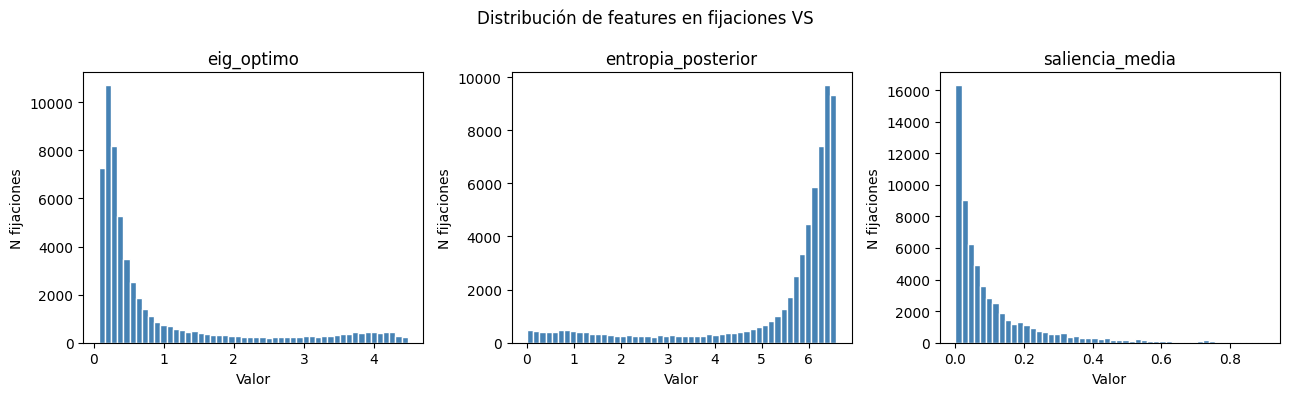

In [16]:
# ── 6. Quick sanity check ────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

feats_plot = ['eig_optimo', 'entropia_posterior', 'saliencia_media']
for ax, feat in zip(axes, feats_plot):
    vals = meta.loc[fix_mask, feat].dropna()
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('Valor')
    ax.set_ylabel('N fijaciones')

plt.suptitle('Distribución de features en fijaciones VS', fontsize=12)
plt.tight_layout()
plt.show()